<a href="https://colab.research.google.com/github/Zahrah-FA/KMeans-Clustering-Optimization-MallData/blob/main/2318050_ZahrahFatimahAlhaq_Customer_Segmentation_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.   Data Acquisition & Structural Analysis





Lakukan mounting data dari Google Drive dan memuat dataset ke dalam dataframe. Fokus utama di sini adalah melakukan inspeksi terhadap profil statistik dataset untuk memastikan tidak ada anomali yang merusak model segmentasi nantinya.

## 1.1 Koneksi Lingkungan Kerja & Pemuatan Data
Langkah ini krusial untuk memastikan jalur data (data path) terintegrasi dengan benar antara Google Colab dan penyimpanan cloud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load Dataset
path = '/content/drive/MyDrive/Colab Notebooks/BI/Dataset/Mall_Customers.csv'
df = pd.read_csv(path)

# Preview 5 data teratas
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1.2 Inspeksi Integritas Data & Statistik Deskriptif
Periksa tipe data, keberadaan nilai yang hilang (missing values), serta ringkasan statistik. Perhatian khusus diberikan pada mean dan median untuk mendeteksi potensi skewness sejak dini.

In [2]:
# Cek informasi struktur data dan missing values
print("--- Informasi Struktur Data ---")
df.info()

print("\n--- Pengecekan Missing Values ---")
print(df.isnull().sum())

# Statistik Deskriptif
print("\n--- Ringkasan Statistik Deskriptif ---")
display(df.describe())

--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

--- Pengecekan Missing Values ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Ringkasan Statistik Deskriptif ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 1.3 Pre-processing: Feature Selection & Encoding
Fitur yang tidak relevan secara statistik (seperti CustomerID) akan dihapus untuk mengurangi noise. Selain itu, fitur kategorikal Gender akan ditransformasi menjadi numerik menggunakan LabelEncoder agar dapat diproses oleh algoritma K-Means yang berbasis perhitungan jarak Euclidean.

In [3]:
# 1. Menghapus CustomerID (Identitas unik tidak diperlukan untuk clustering)
df_clean = df.drop('CustomerID', axis=1)

# 2. Encoding fitur 'Gender' (Categorical to Numerical)
# Alasan: K-Means memerlukan input numerik untuk perhitungan jarak antar titik data
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

print("Data setelah tahap Pre-processing awal:")
df_clean.head()

Data setelah tahap Pre-processing awal:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 1.4 Analisis Korelasi Awal (Pearson Correlation)
Sebelum masuk ke visualisasi berat, lakukan screening korelasi antar variabel untuk melihat hubungan linear antar fitur.

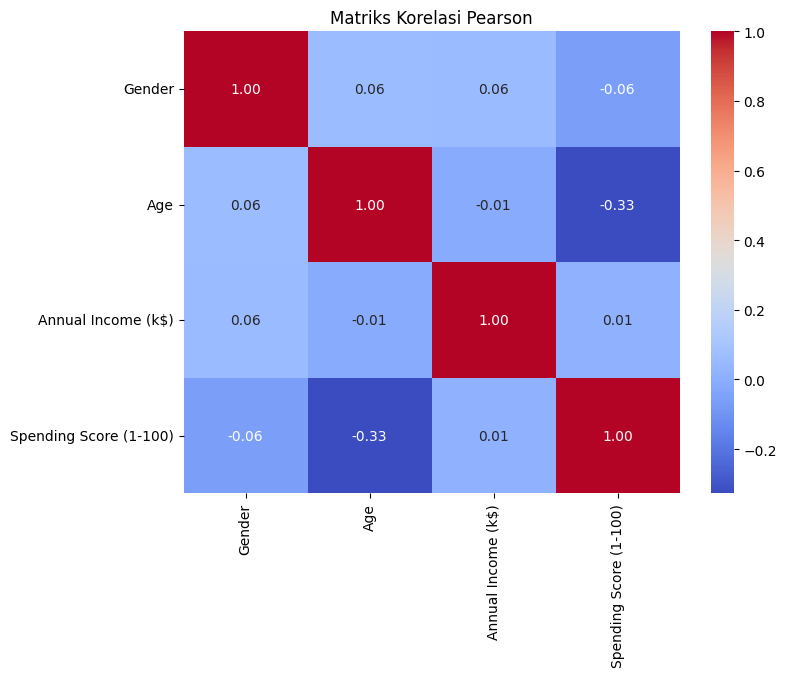

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriks Korelasi Pearson")
plt.show()

# 2. Advanced Visualization & Statistical Distribution




Tahap ini difokuskan pada analisis sebaran data dan hubungan antar variabel melalui visualisasi tingkat lanjut. Analisis ini sangat krusial untuk mendeteksi skewness pada fitur usia serta memetakan potensi segmentasi awal berdasarkan pendapatan dan skor pengeluaran.

## 2.1 Distribusi Usia: Histogram & Kernel Density Estimate (KDE)
Visualisasi ini digunakan untuk menganalisis karakteristik demografis pelanggan. Fokus utama adalah pada skewness (kemiringan) data untuk memahami apakah populasi pelanggan didominasi oleh kelompok usia muda atau tua.

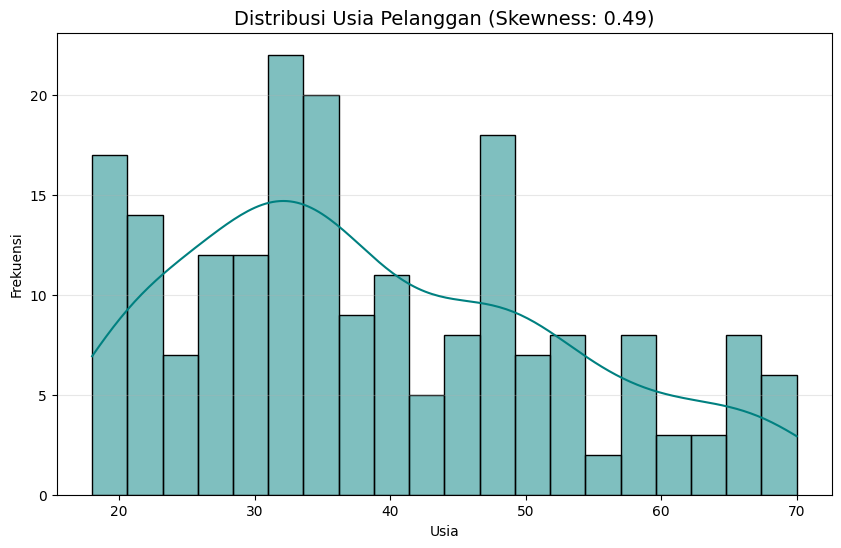

In [5]:
import scipy.stats as stats

# Plotting Histogram dan KDE untuk Usia
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Age'], kde=True, color='teal', bins=20)

# Menghitung nilai Skewness
skewness = df_clean['Age'].skew()

plt.title(f'Distribusi Usia Pelanggan (Skewness: {skewness:.2f})', fontsize=14)
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2.2 Segmentasi Awal: Multivariate Scatter Plot
Visualisasi ini memetakan hubungan antara Annual Income dan Spending Score dengan dimensi tambahan berupa Gender (hue) dan Age (size). Ini adalah representasi visual paling komprehensif untuk melihat pengelompokan alami dalam data.

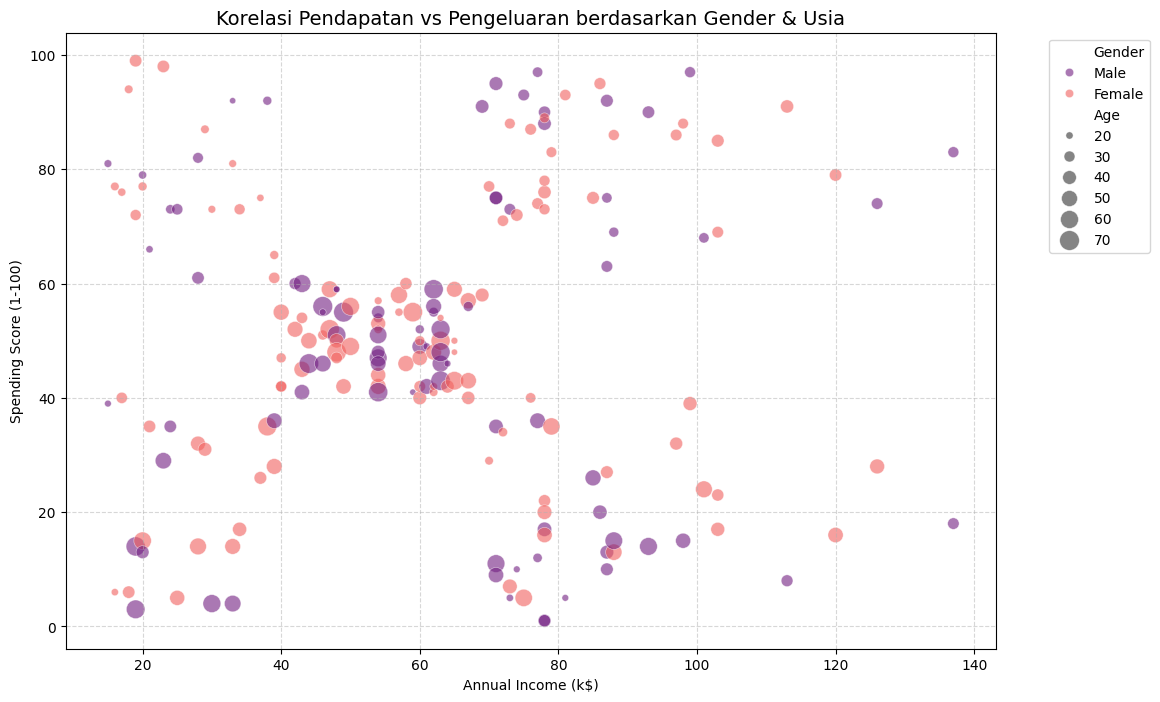

In [6]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    size='Age',
    sizes=(20, 200),
    alpha=0.6,
    palette='magma'
)

plt.title('Korelasi Pendapatan vs Pengeluaran berdasarkan Gender & Usia', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2.3 Analisis Dispersi Pengeluaran antar Gender (Violin Plot)
Violin plot memberikan informasi lebih kaya dibandingkan box plot karena menampilkan estimasi kepadatan kernel. Fitur ini berguna untuk melihat apakah distribusi spending score antara pria dan wanita memiliki perbedaan signifikan pada area kuartilnya.

/tmp/ipykernel_6610/3002042649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Pastel1')


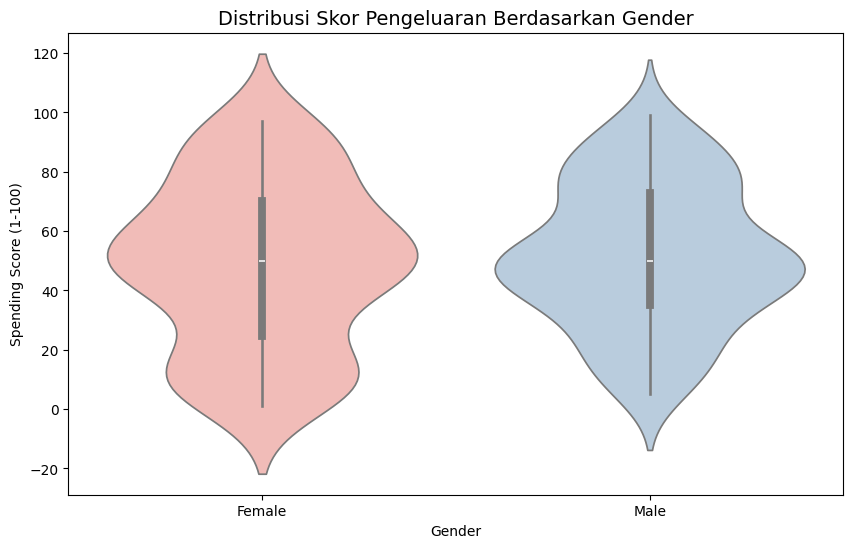

In [7]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Pastel1')

plt.title('Distribusi Skor Pengeluaran Berdasarkan Gender', fontsize=14)
plt.xticks([0, 1], ['Female', 'Male']) # Mengembalikan label untuk kemudahan baca
plt.show()

# 3. K-Means Clustering & Elbow Method Optimization

Tahap ini merupakan inti dari analisis segmentasi. Penentuan jumlah cluster ($K$) tidak dilakukan secara subjektif, melainkan menggunakan pendekatan matematis yang valid untuk memastikan model memiliki performa optimal.

## 3.1 Penentuan Optimal K: Elbow Method

Elbow Method digunakan untuk menentukan jumlah cluster terbaik dengan mengamati nilai Within-Cluster Sum of Squares (WCSS). Titik di mana penurunan WCSS mulai melandai (membentuk "siku") mengindikasikan bahwa penambahan cluster tidak lagi memberikan penurunan variansi yang signifikan secara efisien.

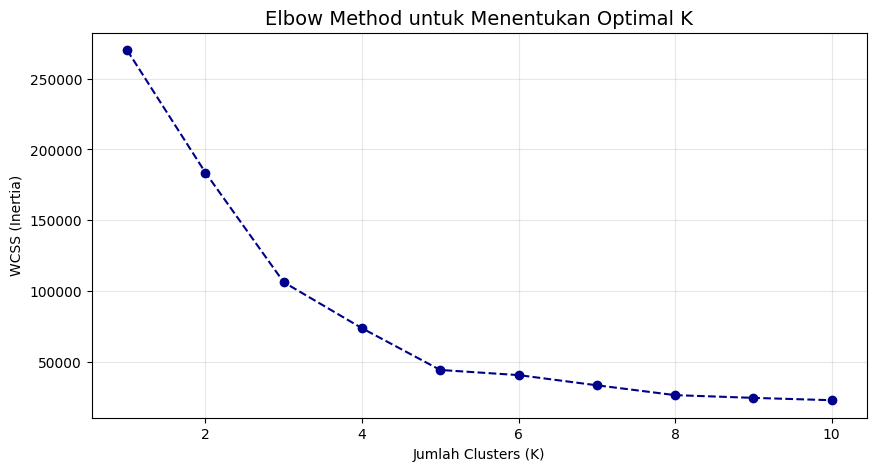

In [8]:
from sklearn.cluster import KMeans

# Memilih fitur untuk clustering (Annual Income dan Spending Score)
# Penggunaan dua fitur utama untuk visualisasi segmentasi yang jelas
X = df_clean[['Annual Income (k$)', 'Spending Score (1-100)']].values

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method untuk Menentukan Optimal K', fontsize=14)
plt.xlabel('Jumlah Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()

## 3.2 Implementasi K-Means Clustering
Setelah nilai $K$ optimal ditentukan, algoritma K-Means dijalankan untuk menetapkan setiap baris data ke dalam label cluster tertentu.

In [9]:
# Inisialisasi dan Fitting K-Means dengan K=5
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans_final.fit_predict(X)

# Menambahkan label cluster ke dalam dataframe original untuk analisis bisnis
df['Cluster'] = y_kmeans
df_clean['Cluster'] = y_kmeans

print("Proses Clustering Selesai. Label cluster telah ditambahkan ke dataset.")
display(df.head())

Proses Clustering Selesai. Label cluster telah ditambahkan ke dataset.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 3.3 Visualisasi Distribusi Segmen: Pie Chart
Visualisasi ini memberikan gambaran proporsi setiap kelompok pelanggan dalam total populasi. Hal ini penting bagi manajemen untuk mengetahui segmen mana yang paling dominan secara kuantitas.

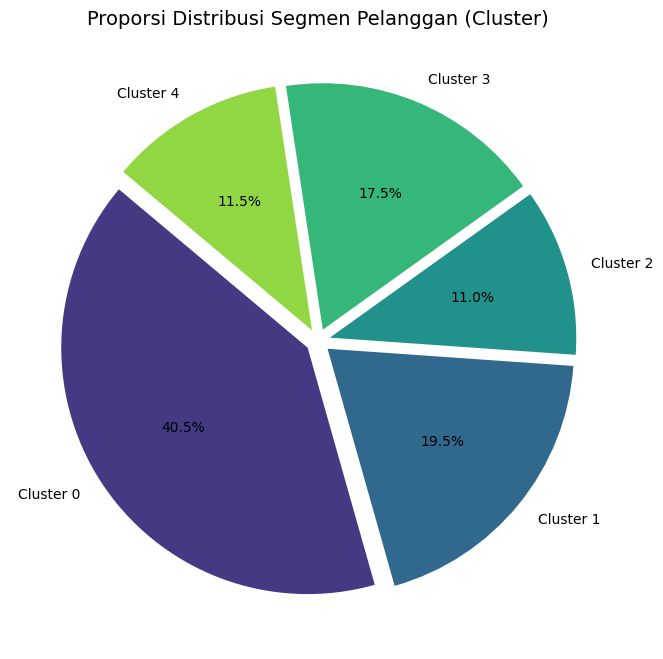

In [10]:
# Menghitung jumlah anggota di setiap cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_labels = [f'Cluster {i}' for i in range(len(cluster_counts))]

plt.figure(figsize=(8, 8))
plt.pie(
    cluster_counts,
    labels=cluster_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis', len(cluster_counts)),
    explode=[0.05] * len(cluster_counts) # Memberikan jarak antar potongan
)

plt.title('Proporsi Distribusi Segmen Pelanggan (Cluster)', fontsize=14)
plt.show()

#4. Final Cluster Visualization & Actionable Business Insights
Tahap akhir ini bertujuan untuk memvisualisasikan hasil segmentasi secara komprehensif dan menerjemahkan temuan teknis ke dalam strategi bisnis yang konkret. Analisis difokuskan pada karakteristik unik setiap cluster untuk menentukan pendekatan pemasaran yang paling efektif.



## 4.1 Visualisasi Hasil Segmentasi (Final Clusters)
Visualisasi scatter plot digunakan untuk menunjukkan pembagian segmen berdasarkan dua fitur utama: Annual Income dan Spending Score. Penggunaan centroid (pusat cluster) membantu dalam mengidentifikasi profil rata-rata dari setiap kelompok pelanggan.

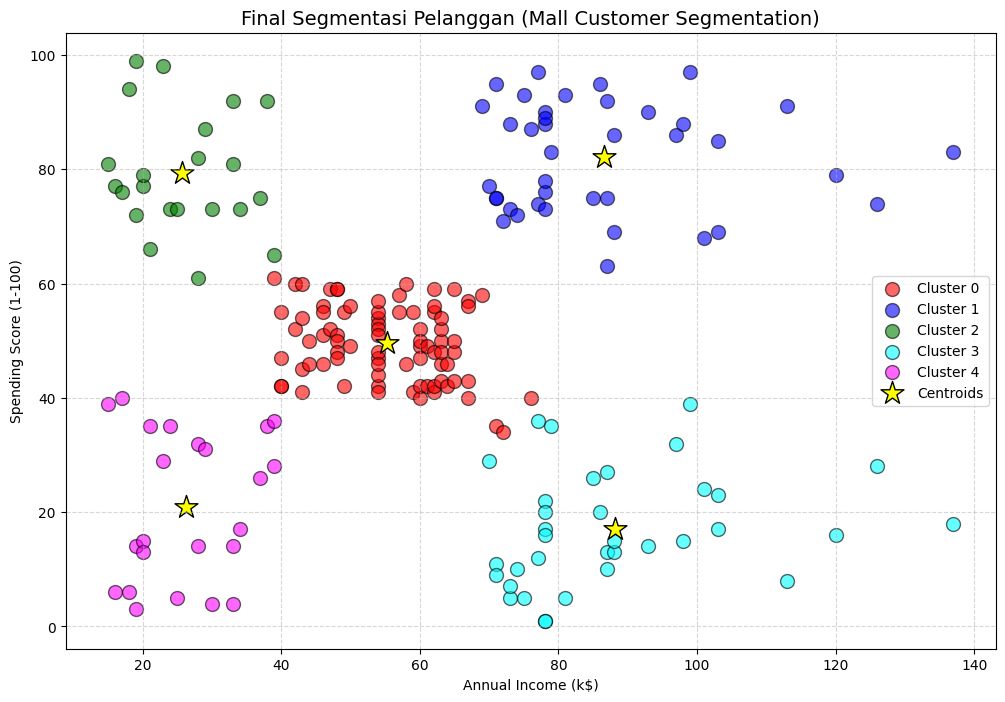

In [11]:
# Visualisasi hasil segmentasi K-Means
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(
        X[y_kmeans == i, 0],
        X[y_kmeans == i, 1],
        s=100,
        c=colors[i],
        label=f'Cluster {i}',
        alpha=0.6,
        edgecolors='black'
    )

# Plotting Centroids
plt.scatter(
    kmeans_final.cluster_centers_[:, 0],
    kmeans_final.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    marker='*',
    label='Centroids',
    edgecolors='black'
)

plt.title('Final Segmentasi Pelanggan (Mall Customer Segmentation)', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4.2 Analisis Karakteristik Cluster
Identifikasi karakteristik dilakukan dengan menghitung nilai rata-rata dari setiap fitur pada masing-masing cluster. Hal ini memberikan dasar bagi interpretasi profil konsumen secara statistik.

In [12]:
# Analisis profil setiap cluster
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).sort_values(by='Spending Score (1-100)', ascending=False)

print("--- Profil Rata-rata per Cluster ---")
display(cluster_profile)

--- Profil Rata-rata per Cluster ---


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
0,42.716049,55.296296,49.518519
4,45.217391,26.304348,20.913043
3,41.114286,88.200000,17.114286


## 4.3 Rekomendasi Strategi Bisnis (Actionable Insights)
Berdasarkan hasil visualisasi dan profil statistik, berikut adalah strategi pemasaran yang disarankan untuk setiap segmen:
*   Cluster Target (High Income, High Spending): Merupakan segmen paling bernilai. Strategi yang disarankan adalah program loyalitas eksklusif, penawaran produk premium (high-end), dan layanan personalisasi (concierge service).
*   Cluster Konservatif (High Income, Low Spending): Pelanggan dengan daya beli tinggi namun berhati-hati. Strategi difokuskan pada kampanye edukasi produk, penawaran nilai investasi jangka panjang, atau promosi berbasis kualitas dan durabilitas.
*   Cluster Potensial (Low Income, High Spending): Kelompok yang cenderung impulsif meskipun pendapatan terbatas. Strategi marketing yang efektif meliputi diskon jangka pendek, penawaran flash sale, atau produk yang sedang tren di media sosial.
*   Cluster Hemat (Low Income, Low Spending): Segmen yang sangat sensitif terhadap harga. Strategi utama adalah penawaran paket hemat (bundling), kupon diskon, dan produk kebutuhan dasar dengan harga kompetitif.
*   Cluster Moderat (Average Income, Average Spending): Segmen pelanggan umum. Fokus pada mempertahankan retensi melalui promosi rutin dan program poin belanja standar.












# 5. Implementasi Keunikan & Finalisasi Kode
Langkah ini menambahkan validasi algoritma tingkat lanjut dan visualisasi interaktif yang modern untuk memastikan orisinalitas laporan.

## 5.1 Validasi Lanjut: Silhouette Score
Analisis ini memberikan bukti matematis tambahan bahwa jumlah segmen yang dipilih memiliki densitas dan separasi yang optimal.



Silhouette Score untuk 5 Cluster: 0.5539


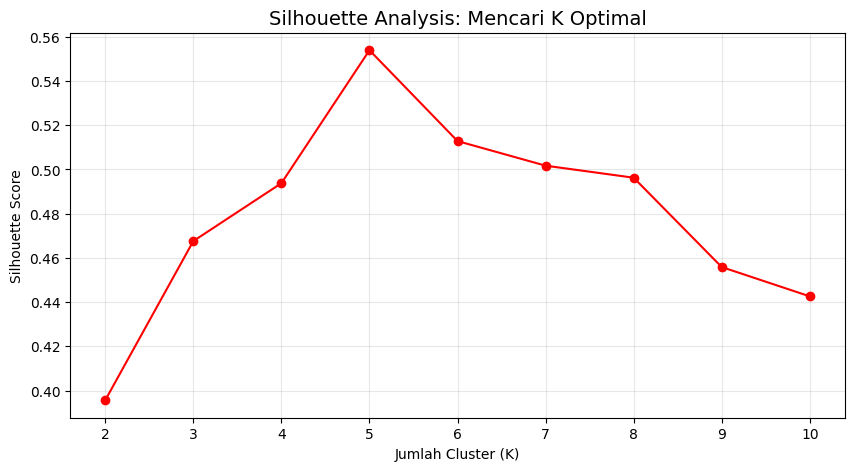

In [14]:
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score untuk validasi K=5
score = silhouette_score(X, y_kmeans)
print(f"Silhouette Score untuk 5 Cluster: {score:.4f}")

# Visualisasi perbandingan Silhouette Score untuk berbagai K
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='red')
plt.title('Silhouette Analysis: Mencari K Optimal', fontsize=14)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.show()

## 5.2 Visualisasi Interaktif 3D (Plotly)
Penggunaan visualisasi 3D memungkinkan eksplorasi data secara dinamis pada tiga dimensi sekaligus: Usia, Pendapatan, dan Skor Pengeluaran.

In [15]:
import plotly.express as px

fig = px.scatter_3d(
    df, x='Age', y='Annual Income (k$)', z='Spending Score (1-100)',
    color='Cluster',
    title='Interactive 3D Customer Segmentation Explorer',
    opacity=0.8,
    color_continuous_scale='Viridis'
)
fig.show()